In [69]:
# For this notebook to run with updated APIs, we need torch 1.12+ and torchvision 0.13+
try:
    import torch
    import torchvision
    assert int(torch.__version__.split(".")[1]) >= 12, "torch version should be 1.12+"
    assert int(torchvision.__version__.split(".")[1]) >= 13, "torchvision version should be 0.13+"
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")
except:
    print(f"[INFO] torch/torchvision versions not as required, installing nightly versions.")
    !pip3 install -U torch torchvision torchaudio --extra-index-url https://download.pytorch.org/whl/cu113
    import torch
    import torchvision
    print(f"torch version: {torch.__version__}")
    print(f"torchvision version: {torchvision.__version__}")

[INFO] torch/torchvision versions not as required, installing nightly versions.
Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu113
torch version: 2.9.1
torchvision version: 0.24.1


In [70]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular or helper_functions scripts... downloading them from GitHub.")
    !git clone https://github.com/mrdbourke/pytorch-deep-learning
    !mv pytorch-deep-learning/going_modular .
    !mv pytorch-deep-learning/helper_functions.py . # get the helper_functions.py script
    !rm -rf pytorch-deep-learning
    from going_modular.going_modular import data_setup, engine
    from helper_functions import download_data, set_seeds, plot_loss_curves

In [71]:
device = torch.device("mps")

In [72]:
# Download pizza, steak, sushi images from GitHub
data_20_percent_path = download_data(source="https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi_20_percent.zip",
                                     destination="pizza_steak_sushi_20_percent")

data_20_percent_path

[INFO] data/pizza_steak_sushi_20_percent directory exists, skipping download.


PosixPath('data/pizza_steak_sushi_20_percent')

In [73]:
# Setup directory paths to train and test images
train_dir = data_20_percent_path / "train"
test_dir = data_20_percent_path / "test"

In [74]:
# 1. Setup pretrained EffNetB2 weights
effnetb2_weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT

# 2. Get EffNetB2 transforms
effnetb2_transforms = effnetb2_weights.transforms()

# 3. Setup pretrained model
effnetb2 = torchvision.models.efficientnet_b2(weights=effnetb2_weights) # could also use weights="DEFAULT"

# 4. Freeze the base layers in the model (this will freeze all layers to begin with)
for param in effnetb2.parameters():
    param.requires_grad = False

In [75]:
# Check out EffNetB2 classifier head
effnetb2.classifier

Sequential(
  (0): Dropout(p=0.3, inplace=True)
  (1): Linear(in_features=1408, out_features=1000, bias=True)
)

In [76]:
# 5. Update the classifier head
effnetb2.classifier = nn.Sequential(
    nn.Dropout(p=0.3, inplace=True), # keep dropout layer same
    nn.Linear(in_features=1408, # keep in_features same 
              out_features=3)) # change out_features to suit our number of classes

In [77]:
def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # 1, 2, 3. Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # 4. Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # 5. Change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

In [78]:
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=3,
                                                      seed=42)
effnetb2=effnetb2.to(device)

In [79]:
# Setup DataLoaders
from going_modular.going_modular import data_setup
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                                 test_dir=test_dir,
                                                                                                 transform=effnetb2_transforms,
                                                                                                 batch_size=32)

In [80]:
from going_modular.going_modular import engine

# Setup optimizer
optimizer = torch.optim.Adam(params=effnetb2.parameters(),
                             lr=1e-3)
# Setup loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Set seeds for reproducibility and train the model
set_seeds()
effnetb2_results = engine.train(model=effnetb2,
                                train_dataloader=train_dataloader_effnetb2,
                                test_dataloader=test_dataloader_effnetb2,
                                epochs=1,
                                optimizer=optimizer,
                                loss_fn=loss_fn,
                                device=device)

  0%|          | 0/1 [00:00<?, ?it/s]

/Users/abdrhmn/.pyenv/versions/pytorch/lib/python3.10/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Epoch: 1 | train_loss: 0.9817 | train_acc: 0.5729 | test_loss: 0.7343 | test_acc: 0.9625


In [81]:
# تحقق من توفر MPS
if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("✅ Using MPS (Apple Silicon GPU)")
elif torch.cuda.is_available():
    device = torch.device("cuda")
    print("✅ Using CUDA")
else:
    device = torch.device("cpu")
    print("⚠️ Using CPU - This will be slow!")

print(f"Device: {device}")

✅ Using MPS (Apple Silicon GPU)
Device: mps


In [82]:
# نقل النموذج إلى MPS
effnetb2 = effnetb2.to(device)

# تأكد من أن البيانات تُنقل أيضاً (عادة يتم ذلك في engine.train)

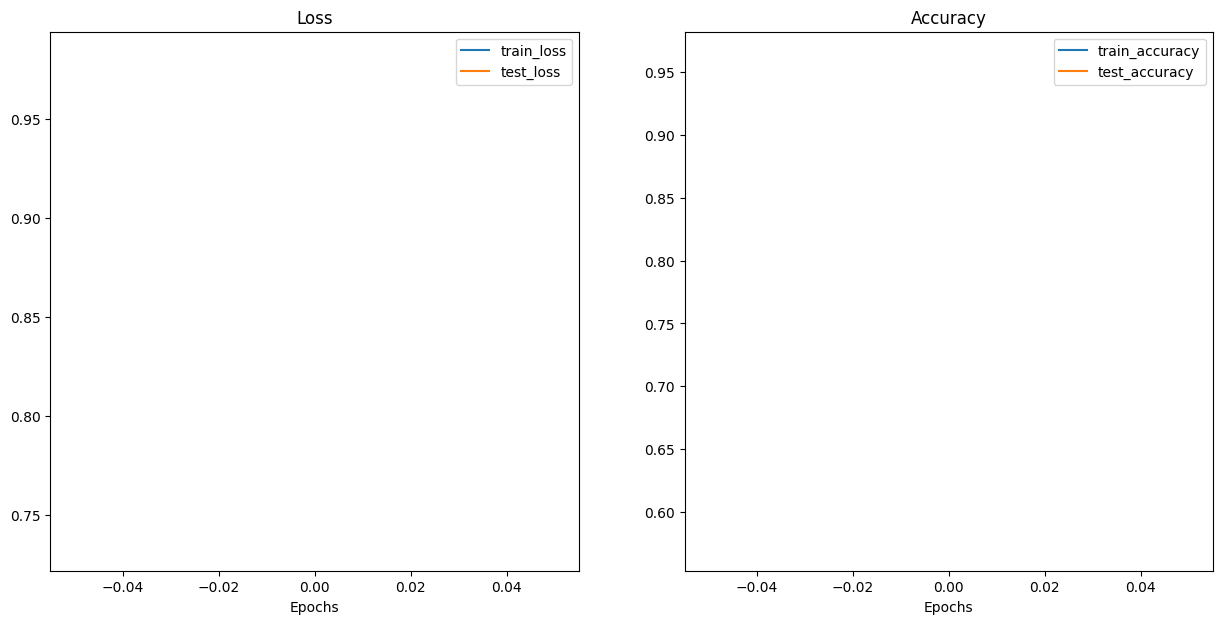

In [83]:
from helper_functions import plot_loss_curves
plot_loss_curves(effnetb2_results)

In [84]:
# في Terminal
!pip install --upgrade torch torchvision torchaudio

In [85]:
!pip3 install --pre torch torchvision torchaudio --index-url https://download.pytorch.org/whl/nightly/cpu

Looking in indexes: https://download.pytorch.org/whl/nightly/cpu


In [86]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"MPS available: {torch.backends.mps.is_available()}")
print(f"MPS built: {torch.backends.mps.is_built()}")

# اختبار سرعة MPS
if torch.backends.mps.is_available():
    # اختبار بسيط
    import time
    
    device_mps = torch.device("mps")
    device_cpu = torch.device("cpu")
    
    # إنشاء tensor كبير
    size = 5000
    
    # على CPU
    a_cpu = torch.randn(size, size)
    b_cpu = torch.randn(size, size)
    start = time.time()
    c_cpu = torch.matmul(a_cpu, b_cpu)
    cpu_time = time.time() - start
    print(f"CPU time: {cpu_time:.3f}s")
    
    # على MPS
    a_mps = torch.randn(size, size, device=device_mps)
    b_mps = torch.randn(size, size, device=device_mps)
    
    # Warm up
    torch.matmul(a_mps, b_mps)
    torch.mps.synchronize()
    
    start = time.time()
    c_mps = torch.matmul(a_mps, b_mps)
    torch.mps.synchronize()
    mps_time = time.time() - start
    print(f"MPS time: {mps_time:.3f}s")
    print(f"Speedup: {cpu_time/mps_time:.1f}x")

PyTorch version: 2.9.1
MPS available: True
MPS built: True


CPU time: 0.102s
MPS time: 0.038s
Speedup: 2.7x


In [87]:
# تأكد من نقل النموذج إلى MPS
device = torch.device("mps")
effnetb2 = effnetb2.to(device)

print(f"Model is on: {next(effnetb2.parameters()).device}")

Model is on: mps:0


In [88]:
import torch
import torchvision
from torch import nn

# 1. إعداد الجهاز
device = torch.device("mps")
print(f"✅ Using device: {device}")

# 2. إنشاء النموذج
def create_effnetb2_model(num_classes=3, seed=42):
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)
    
    # تجميد الطبقات
    for param in model.parameters():
        param.requires_grad = False
    
    # تغيير الـ classifier
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

# 3. إنشاء النموذج ونقله إلى MPS
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=3, seed=42)
effnetb2 = effnetb2.to(device)  # ⬅️ مهم جداً!

# 4. التحقق
print(f"✅ Model is on: {next(effnetb2.parameters()).device}")

# 5. إعداد DataLoaders مع تحسينات
train_dataloader_effnetb2, test_dataloader_effnetb2, class_names = data_setup.create_dataloaders(
    train_dir=train_dir,
    test_dir=test_dir,
    transform=effnetb2_transforms,
    batch_size=64,      # ⬅️ زيادة batch size
    num_workers=0       # ⬅️ 0 أفضل مع MPS
)

# 6. التدريب
optimizer = torch.optim.Adam(params=effnetb2.parameters(), lr=1e-3)
loss_fn = torch.nn.CrossEntropyLoss()

set_seeds()
effnetb2_results = engine.train(
    model=effnetb2,
    train_dataloader=train_dataloader_effnetb2,
    test_dataloader=test_dataloader_effnetb2,
    epochs=10,
    optimizer=optimizer,
    loss_fn=loss_fn,
    device=device  # ⬅️ تأكد من تمرير device
)

✅ Using device: mps
✅ Model is on: mps:0


  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0297 | train_acc: 0.5039 | test_loss: 0.8726 | test_acc: 0.8717
Epoch: 2 | train_loss: 0.8088 | train_acc: 0.7988 | test_loss: 0.7172 | test_acc: 0.8977
Epoch: 3 | train_loss: 0.7322 | train_acc: 0.8125 | test_loss: 0.6092 | test_acc: 0.9688
Epoch: 4 | train_loss: 0.5638 | train_acc: 0.9102 | test_loss: 0.5404 | test_acc: 0.9375
Epoch: 5 | train_loss: 0.5478 | train_acc: 0.8438 | test_loss: 0.5055 | test_acc: 0.9588
Epoch: 6 | train_loss: 0.5939 | train_acc: 0.8516 | test_loss: 0.4676 | test_acc: 0.9740
Epoch: 7 | train_loss: 0.5464 | train_acc: 0.7832 | test_loss: 0.4215 | test_acc: 0.9479
Epoch: 8 | train_loss: 0.5841 | train_acc: 0.7871 | test_loss: 0.4328 | test_acc: 0.9640
Epoch: 9 | train_loss: 0.4831 | train_acc: 0.8770 | test_loss: 0.4399 | test_acc: 0.9176
Epoch: 10 | train_loss: 0.5128 | train_acc: 0.7930 | test_loss: 0.3906 | test_acc: 0.9432


In [89]:
# الطريقة الصحيحة لأجهزة Mac
device = torch.device("mps")

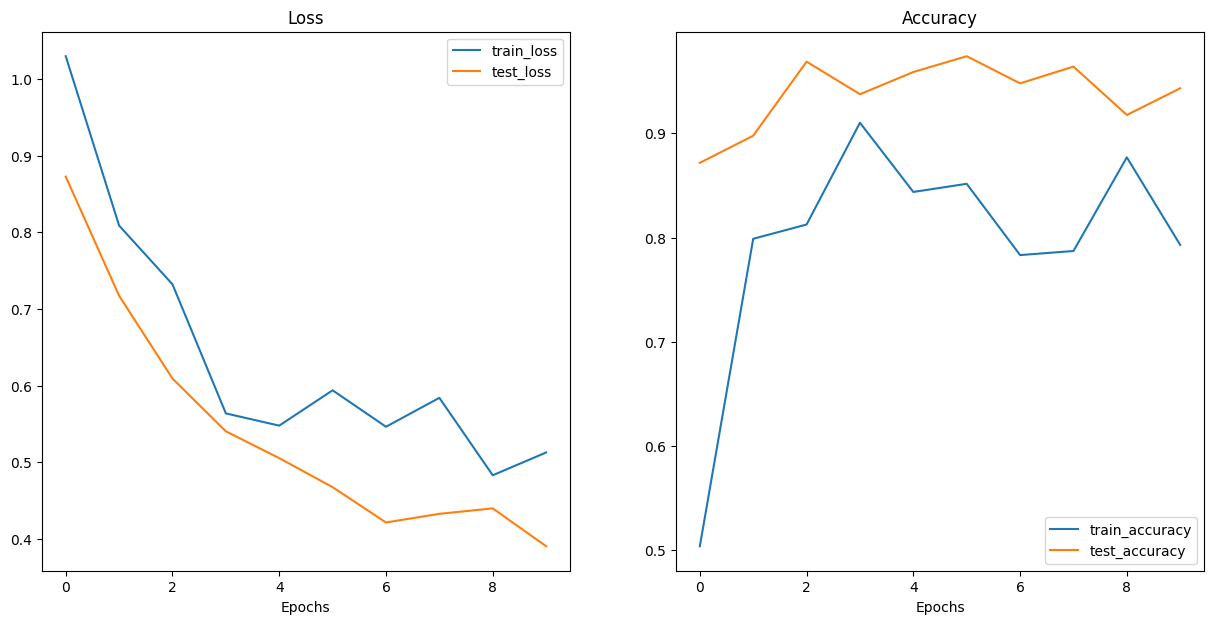

In [90]:
from helper_functions import plot_loss_curves

plot_loss_curves(effnetb2_results)

In [91]:
from going_modular.going_modular import utils

# Save the model
utils.save_model(model=effnetb2,
                 target_dir="models",
                 model_name="09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth


In [92]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_effnetb2_model_size = Path("models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly) 
print(f"Pretrained EffNetB2 feature extractor model size: {pretrained_effnetb2_model_size} MB")

Pretrained EffNetB2 feature extractor model size: 29 MB


In [93]:
# Count number of parameters in EffNetB2
effnetb2_total_params = sum(torch.numel(param) for param in effnetb2.parameters())
effnetb2_total_params

7705221

In [94]:
# Create a dictionary with EffNetB2 statistics
effnetb2_stats = {"test_loss": effnetb2_results["test_loss"][-1],
                  "test_acc": effnetb2_results["test_acc"][-1],
                  "number_of_parameters": effnetb2_total_params,
                  "model_size (MB)": pretrained_effnetb2_model_size}
effnetb2_stats

{'test_loss': 0.3905764122804006,
 'test_acc': 0.9431818181818182,
 'number_of_parameters': 7705221,
 'model_size (MB)': 29}

In [95]:
# Check out ViT heads layer
device = torch.device("mps")
vit = torchvision.models.vit_b_16().to(device)
vit.heads

Sequential(
  (head): Linear(in_features=768, out_features=1000, bias=True)
)

In [96]:
def create_vit_model(num_classes:int=3, 
                     seed:int=42):
    """Creates a ViT-B/16 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of target classes. Defaults to 3.
        seed (int, optional): random seed value for output layer. Defaults to 42.

    Returns:
        model (torch.nn.Module): ViT-B/16 feature extractor model. 
        transforms (torchvision.transforms): ViT-B/16 image transforms.
    """
    # Create ViT_B_16 pretrained weights, transforms and model
    weights = torchvision.models.ViT_B_16_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.vit_b_16(weights=weights).to(device)

    # Freeze all layers in model
    for param in model.parameters():
        param.requires_grad = False

    # Change classifier head to suit our needs (this will be trainable)
    torch.manual_seed(seed)
    model.heads = nn.Sequential(nn.Linear(in_features=768, # keep this the same as original model
                                          out_features=num_classes)) # update to reflect target number of classes
    
    return model, transforms

In [97]:
# Create ViT model and transforms
vit, vit_transforms = create_vit_model(num_classes=3,
                                       seed=42)
vit = vit.to(device)

In [98]:
# Setup ViT DataLoaders
from going_modular.going_modular import data_setup
train_dataloader_vit, test_dataloader_vit, class_names = data_setup.create_dataloaders(train_dir=train_dir,
                                                                                       test_dir=test_dir,
                                                                                       transform=vit_transforms,
                                                                                       batch_size=64,num_workers=0)

In [99]:
from going_modular.going_modular import engine

# Setup optimizer
optimizer = torch.optim.Adam(params=vit.parameters(),
                             lr=1e-3)
# Setup loss function
loss_fn = torch.nn.CrossEntropyLoss()

# Train ViT model with seeds set for reproducibility
set_seeds()
vit_results = engine.train(model=vit,
                           train_dataloader=train_dataloader_vit,
                           test_dataloader=test_dataloader_vit,
                           epochs=10,
                           optimizer=optimizer,
                           loss_fn=loss_fn,
                           device=device)

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 0.8948 | train_acc: 0.6387 | test_loss: 0.5185 | test_acc: 0.8726
Epoch: 2 | train_loss: 0.4040 | train_acc: 0.8711 | test_loss: 0.3359 | test_acc: 0.9233
Epoch: 3 | train_loss: 0.2845 | train_acc: 0.9414 | test_loss: 0.2482 | test_acc: 0.9285
Epoch: 4 | train_loss: 0.1796 | train_acc: 0.9590 | test_loss: 0.1863 | test_acc: 0.9541
Epoch: 5 | train_loss: 0.1689 | train_acc: 0.9629 | test_loss: 0.1539 | test_acc: 0.9692
Epoch: 6 | train_loss: 0.2084 | train_acc: 0.9023 | test_loss: 0.1288 | test_acc: 0.9692
Epoch: 7 | train_loss: 0.1262 | train_acc: 0.9609 | test_loss: 0.1196 | test_acc: 0.9692
Epoch: 8 | train_loss: 0.1928 | train_acc: 0.9023 | test_loss: 0.1106 | test_acc: 0.9744
Epoch: 9 | train_loss: 0.1468 | train_acc: 0.9707 | test_loss: 0.1099 | test_acc: 0.9744
Epoch: 10 | train_loss: 0.1145 | train_acc: 0.9785 | test_loss: 0.1003 | test_acc: 0.9796


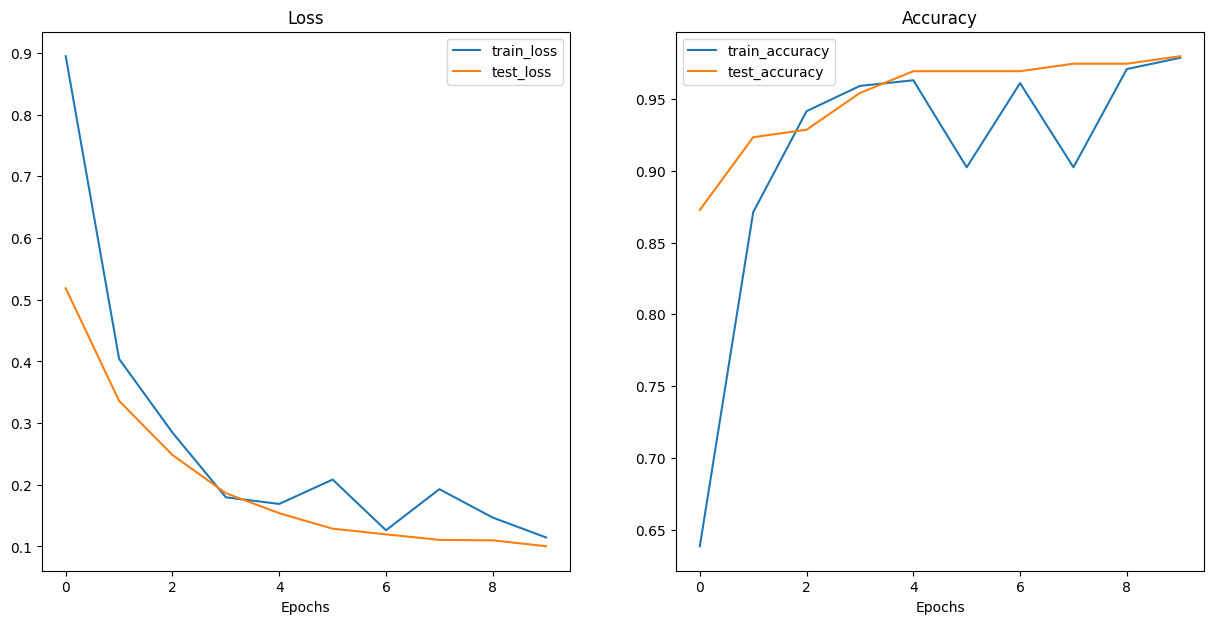

In [100]:
from helper_functions import plot_loss_curves

plot_loss_curves(vit_results)

In [101]:
# Save the model
from going_modular.going_modular import utils

utils.save_model(model=vit,
                 target_dir="models",
                 model_name="09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth")

[INFO] Saving model to: models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth


In [102]:
from pathlib import Path

# Get the model size in bytes then convert to megabytes
pretrained_vit_model_size = Path("models/09_pretrained_vit_feature_extractor_pizza_steak_sushi_20_percent.pth").stat().st_size // (1024*1024) # division converts bytes to megabytes (roughly) 
print(f"Pretrained ViT feature extractor model size: {pretrained_vit_model_size} MB")

Pretrained ViT feature extractor model size: 327 MB


In [103]:
# Count number of parameters in ViT
vit_total_params = sum(torch.numel(param) for param in vit.parameters())
vit_total_params

85800963

In [104]:
# Create ViT statistics dictionary
vit_stats = {"test_loss": vit_results["test_loss"][-1],
             "test_acc": vit_results["test_acc"][-1],
             "number_of_parameters": vit_total_params,
             "model_size (MB)": pretrained_vit_model_size}

vit_stats

{'test_loss': 0.10033089915911357,
 'test_acc': 0.9796401515151515,
 'number_of_parameters': 85800963,
 'model_size (MB)': 327}

In [105]:
from pathlib import Path
test_data_paths=list(Path(test_dir).glob("*/*.jpg"))
test_data_paths[:5]

[PosixPath('data/pizza_steak_sushi_20_percent/test/steak/413497.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2246332.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2475366.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/1982192.jpg'),
 PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2353677.jpg')]

In [106]:
import pathlib
import torch
from PIL import Image
from timeit import default_timer as timer
from tqdm.auto import tqdm
from typing import List, Tuple, Dict
from torchvision import transforms

def pred_and_store (pathes: List[pathlib.Path],
                    model: torch.nn.Module,
                    transform:torchvision.transforms,
                    class_names:List[str],
                    device:str="mps"):
    
    
    pred_list = []
    model = model.to(device)
    model.eval()
    for path in tqdm(pathes):
        pred_dict = {}
        pred_dict["image_path"] = path
        # Load and preprocess image
        class_name=path.parent.stem
        pred_dict['class_name']=class_name
        start_time = timer()
        img=Image.open(path)
        transformed_image=transform(img).unsqueeze(0).to(device)
        
        model=model.to(device)
        model.eval()
        with torch.inference_mode():
            pred_logit=model(transformed_image)
            pred_prob=torch.softmax(pred_logit,dim=1)
            pred_label=torch.argmax(pred_prob,dim=1)
            pred_class=class_names[pred_label.cpu().item()]
            pred_dict["pred_prob"] = round(pred_prob.unsqueeze(0).max().cpu().item(), 4)
            pred_dict['pred_class'] = pred_class
            end_time = timer()
            pred_dict["time_for_pred"] = round(end_time-start_time, 4)
        pred_dict["correct"]=class_name==pred_class
        pred_list.append(pred_dict)
    return pred_list
        
        
    
    
    
    




In [107]:
# اختبار الدالة
effnetb2_preds = pred_and_store(
    pathes=test_data_paths,
    model=effnetb2,
    transform=effnetb2_transforms,
    class_names=class_names,
    device="mps"
)

# عرض أول نتيجة
print(effnetb2_preds[0])

  0%|          | 0/150 [00:00<?, ?it/s]

{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/413497.jpg'), 'class_name': 'steak', 'pred_prob': 0.8831, 'pred_class': 'steak', 'time_for_pred': 0.0242, 'correct': True}


In [108]:
effnetb2_test_pred_dicts= pred_and_store(pathes=test_data_paths,
                                         model=effnetb2,
                                         transform=effnetb2_transforms,
                                            class_names=class_names,
                                            device="mps")
effnetb2_test_pred_dicts[:3]

  0%|          | 0/150 [00:00<?, ?it/s]

[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/413497.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.8831,
  'pred_class': 'steak',
  'time_for_pred': 0.0157,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2246332.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.8537,
  'pred_class': 'steak',
  'time_for_pred': 0.0153,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2475366.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.8417,
  'pred_class': 'steak',
  'time_for_pred': 0.0147,
  'correct': True}]

In [109]:
!pip install pandas

In [110]:
import pandas as pd
effnetb2_test_pred_df=pd.DataFrame(effnetb2_test_pred_dicts)
effnetb2_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/steak/4...,steak,0.8831,steak,0.0157,True
1,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.8537,steak,0.0153,True
2,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.8417,steak,0.0147,True
3,data/pizza_steak_sushi_20_percent/test/steak/1...,steak,0.6222,steak,0.0153,True
4,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.6124,steak,0.0146,True


In [111]:
effnetb2_avareage_pred_time=round(effnetb2_test_pred_df.time_for_pred.mean(),4)
effnetb2_avareage_pred_time

np.float64(0.0146)

In [112]:
vit_test_pred_dicts= pred_and_store(pathes=test_data_paths,model=vit,transform=vit_transforms,class_names=class_names,device="mps")
vit_test_pred_dicts[:3]

  0%|          | 0/150 [00:00<?, ?it/s]

[{'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/413497.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.8527,
  'pred_class': 'steak',
  'time_for_pred': 0.0565,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2246332.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.9967,
  'pred_class': 'steak',
  'time_for_pred': 0.0402,
  'correct': True},
 {'image_path': PosixPath('data/pizza_steak_sushi_20_percent/test/steak/2475366.jpg'),
  'class_name': 'steak',
  'pred_prob': 0.9921,
  'pred_class': 'steak',
  'time_for_pred': 0.0398,
  'correct': True}]

In [113]:
import pandas as pd
vit_test_pred_df=pd.DataFrame(vit_test_pred_dicts)
vit_test_pred_df.head()

,image_path,class_name,pred_prob,pred_class,time_for_pred,correct
0,data/pizza_steak_sushi_20_percent/test/steak/4...,steak,0.8527,steak,0.0565,True
1,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.9967,steak,0.0402,True
2,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.9921,steak,0.0398,True
3,data/pizza_steak_sushi_20_percent/test/steak/1...,steak,0.9770,steak,0.0404,True
4,data/pizza_steak_sushi_20_percent/test/steak/2...,steak,0.9009,steak,0.0392,True


In [114]:
vit_test_pred_df.correct.value_counts()

correct
True     148
False      2
Name: count, dtype: int64

In [115]:
vit_average_time_per_pred=round(vit_test_pred_df.time_for_pred.mean(),4)
print(vit_average_time_per_pred)

0.0395


In [116]:
vit_stats["time_per_pred (s)"]=vit_average_time_per_pred
effnetb2_average_time_per_pred=round(effnetb2_test_pred_df.time_for_pred.mean(),4)


In [117]:
df=pd.DataFrame([effnetb2_stats,vit_stats])
df["model"]=["effnetb2","vit"]
df["test_accuracy (%)"]=round(df["test_acc"]*100,2)
df

,test_loss,test_acc,number_of_parameters,model_size (MB),time_per_pred (s),model,test_accuracy (%)
0,0.390576,0.943182,7705221,29,NaN,effnetb2,94.32
1,0.100331,0.979640,85800963,327,0.0395,vit,97.96


In [118]:
pd.DataFrame(data=(df.set_index("model").loc["vit"]/df.set_index("model").loc["effnetb2"]),
                              columns=["vit vs effnetb2"]).T

,test_loss,test_acc,number_of_parameters,model_size (MB),time_per_pred (s),test_accuracy (%)
vit vs effnetb2,0.256879,1.038655,11.135432,11.275862,NaN,1.038592


/var/folders/93/88t9xxwd3n1584x6032fbwnc0000gn/T/ipykernel_81448/3387052692.py:4: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter= ax.scatter(data=df,


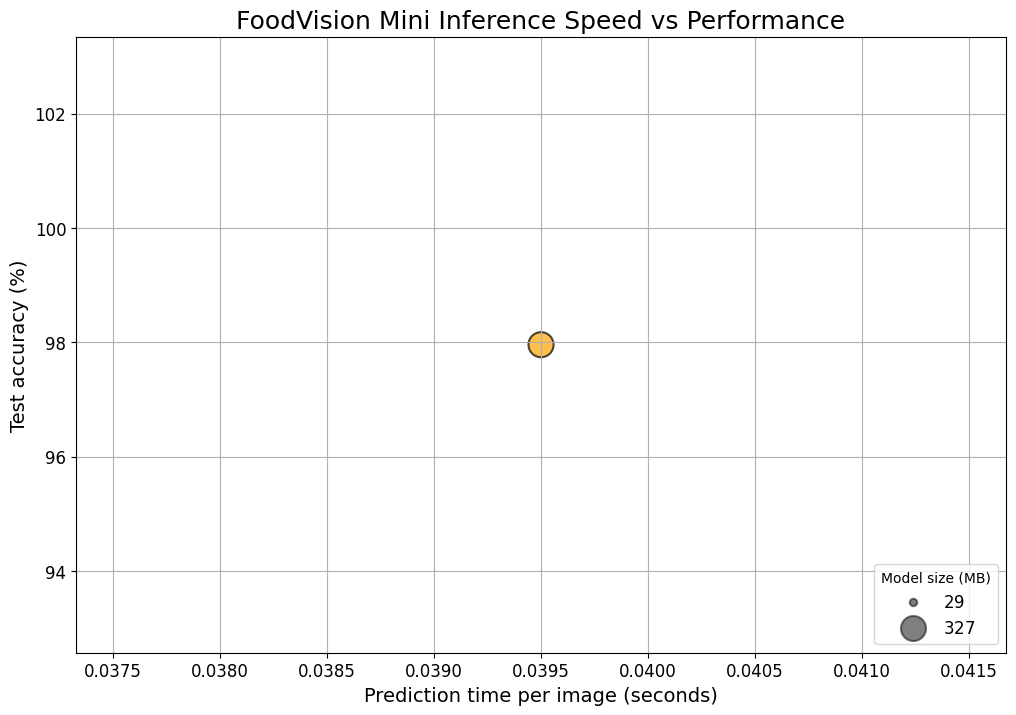

In [119]:
import matplotlib.pyplot as plt
import matplotlib
fig , ax = plt.subplots(figsize=(12,8))
scatter= ax.scatter(data=df,
                    x="time_per_pred (s)",
                    y="test_accuracy (%)",
                    s="model_size (MB)",
                    c=['blue','orange'],
                    cmap=matplotlib.colormaps["Set1"],
                    alpha=0.7,
                    edgecolors="black",
                    linewidth=1.5)  

# 2. Add titles, labels and customize fontsize for aesthetics
ax.set_title("FoodVision Mini Inference Speed vs Performance", fontsize=18)
ax.set_xlabel("Prediction time per image (seconds)", fontsize=14)
ax.set_ylabel("Test accuracy (%)", fontsize=14)
ax.tick_params(axis='both', labelsize=12)
ax.grid(True)

# 3. Annotate with model names
for index, row in df.iterrows():
    ax.annotate(text=row["model"], # note: depending on your version of Matplotlib, you may need to use "s=..." or "text=...", see: https://github.com/faustomorales/keras-ocr/issues/183#issuecomment-977733270 
                xy=(row["time_per_pred (s)"]+0.0006, row["test_acc"]+0.03),
                size=12)

# 4. Create a legend based on model sizes
handles, labels = scatter.legend_elements(prop="sizes", alpha=0.5)
model_size_legend = ax.legend(handles, 
                              labels, 
                              loc="lower right", 
                              title="Model size (MB)",
                              fontsize=12)

# Save the figure
#!mdkir images/
#plt.savefig("images/09-foodvision-mini-inference-speed-vs-performance.jpg")

# Show the figure
plt.show()

In [120]:
try:
    import gradio as gr
    print(f"✅ Gradio version: {gr.__version__}")
except:
    !pip install -q gradio
    import gradio as gr
    print(f"✅ Gradio version: {gr.__version__}")

✅ Gradio version: 6.2.0


In [121]:
effnetb2=effnetb2.to("cpu")
next(iter(effnetb2.parameters())).device


device(type='cpu')

In [122]:
from typing import Tuple, List, Dict
from PIL import Image

def predict(img)->Tuple[Dict,float]:
    start_time = timer()
    img= effnetb2_transforms(img).unsqueeze(0).to("cpu")
    effnetb2.eval()
    with torch.inference_mode():
        pred_probs= torch.softmax(effnetb2(img),dim=1)
    pred_labels_and_probs={class_names[i]:float(pred_probs[0][i]) for i in range(len(class_names))}
    end_time = timer()
    pred_time= round(end_time - start_time,4)
    return pred_labels_and_probs, pred_time

    

In [123]:
import random 
from PIL import Image
test_data_paths=list(Path(test_dir).glob("*/*.jpg"))
random_image_path=random.sample(test_data_paths,k=1)[0]
image=Image.open(random_image_path)
pred_dict, pred_time = predict(img=image)


In [124]:
example_list=[[str(filepath) for filepath in random.sample(test_data_paths,k=5)]]
example_list

[['data/pizza_steak_sushi_20_percent/test/steak/670345.jpg',
  'data/pizza_steak_sushi_20_percent/test/steak/1335842.jpg',
  'data/pizza_steak_sushi_20_percent/test/steak/40947.jpg',
  'data/pizza_steak_sushi_20_percent/test/sushi/3834718.jpg',
  'data/pizza_steak_sushi_20_percent/test/sushi/593071.jpg']]

In [125]:
import gradio as gr
title="Food Vision Mini Model Deployment Demo 😍"
description="A demo for Food Vision Mini models trained on pizza, steak and sushi images (20% of dataset). Models include EfficientNetB2 and ViT-B/16 feature extractors. Upload an image to see the model predictions!"
articles="https://www.learnpytorch.io/09_pytorch_model_deployment/#deploying-food-vision-mini-models-with-gradio"
demo=gr.Interface(fn=predict,
                  inputs=gr.Image(type="pil"),
                  outputs=[gr.Label(num_top_classes=3,label="Predicted class probabilities"),
                           gr.Number(label="Prediction time (s)")],
                  examples=example_list,
                  title=title,
                  description=description)
demo.launch()  


* Running on local URL:  http://127.0.0.1:7861
* To create a public link, set `share=True` in `launch()`.


In [126]:
!pip install pathlib

In [127]:
import shutil
from pathlib import Path

# Create FoodVision mini demo path
foodvision_mini_demo_path = Path("demos/foodvision_mini/")

# Remove files that might already exist there and create new directory
if foodvision_mini_demo_path.exists():
    shutil.rmtree(foodvision_mini_demo_path)
# If the file doesn't exist, create it anyway
foodvision_mini_demo_path.mkdir(parents=True, 
                                exist_ok=True)
    
# Check what's in the folder
!ls demos/foodvision_mini/

In [128]:
foodvision_mini_examples_path=foodvision_mini_demo_path / "examples"
foodvision_mini_examples_path.mkdir(parents=True,exist_ok=True)

foodvision_mini_examples = [Path('data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg'),
                            Path('data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg')]


for example in foodvision_mini_examples:
    destination=foodvision_mini_examples_path / example.name
    print(f"Copying {example} to {destination}...")
    shutil.copy(src=example,dst=destination)
    

Copying data/pizza_steak_sushi_20_percent/test/sushi/592799.jpg to demos/foodvision_mini/examples/592799.jpg...
Copying data/pizza_steak_sushi_20_percent/test/steak/3622237.jpg to demos/foodvision_mini/examples/3622237.jpg...
Copying data/pizza_steak_sushi_20_percent/test/pizza/2582289.jpg to demos/foodvision_mini/examples/2582289.jpg...


In [131]:
import os 
example_list=[["examples/" for example in os.listdir(foodvision_mini_examples_path)]]
example_list

[['examples/', 'examples/', 'examples/']]

In [132]:
import shutil

# Create a source path for our target model
effnetb2_foodvision_mini_model_path = "models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth"

# Create a destination path for our target model 
effnetb2_foodvision_mini_model_destination = foodvision_mini_demo_path / effnetb2_foodvision_mini_model_path.split("/")[1]

# Try to move the file
try:
    print(f"[INFO] Attempting to move {effnetb2_foodvision_mini_model_path} to {effnetb2_foodvision_mini_model_destination}")
    
    # Move the model
    shutil.move(src=effnetb2_foodvision_mini_model_path, 
                dst=effnetb2_foodvision_mini_model_destination)
    
    print(f"[INFO] Model move complete.")

# If the model has already been moved, check if it exists
except:
    print(f"[INFO] No model found at {effnetb2_foodvision_mini_model_path}, perhaps its already been moved?")
    print(f"[INFO] Model exists at {effnetb2_foodvision_mini_model_destination}: {effnetb2_foodvision_mini_model_destination.exists()}")

[INFO] Attempting to move models/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth to demos/foodvision_mini/09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth
[INFO] Model move complete.


In [ ]:
Path("demos/foodvision_mini").mkdir(parents=True, exist_ok=True)


In [ ]:
%%writefile demos/foodvision_mini/model.py
import torch
import torchvision

from torch import nn


def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # Change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

Overwriting demos/foodvision_mini/model.py


In [ ]:
%%writefile demos/foodvision_mini/app.py 
import gradio as gr 
import os 
import torch 
from model import create_effnetb2_model
from pathlib import Path
from timeit import default_timer as timer
from typing import List, Tuple, Dict
from PIL import Image
from torchvision import transforms
class_names = ['pizza', 'steak', 'sushi']
effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=3,
                                                      seed=42)
effnetb2.load_state_dict(torch.load("09_pretrained_effnetb2_feature_extractor_pizza_steak_sushi_20_percent.pth", map_location=torch.device('cpu')))
effnetb2=effnetb2.to("cpu")

def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()
    
    # Transform the target image and add a batch dimension
    img = effnetb2_transforms(img).unsqueeze(0)
    
    # Put model into evaluation mode and turn on inference mode
    effnetb2.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(effnetb2(img), dim=1)
    
    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)
    
    # Return the prediction dictionary and prediction time 
    return pred_labels_and_probs, pred_time

### 4. Gradio app ###

# Create title, description and article strings
title = "FoodVision Mini 🍕🥩🍣"
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food as pizza, steak or sushi."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# Create examples list from "examples/" directory
example_list = [["examples/" + example] for example in os.listdir("examples")]

# Create the Gradio demo
demo = gr.Interface(fn=predict, # mapping function from input to output
                    inputs=gr.Image(type="pil"), # what are the inputs?
                    outputs=[gr.Label(num_top_classes=3, label="Predictions"), # what are the outputs?
                             gr.Number(label="Prediction time (s)")], # our fn has two outputs, therefore we have two outputs
                    # Create examples list from "examples/" directory
                    examples=example_list, 
                    title=title,
                    description=description,
                    article=article)
# Launch the demo!
demo.launch()



Writing demos/foodvision_mini/app.py


In [ ]:
print (torch.__version__)
print (torchvision.__version__)
print (gr.__version__)

2.9.1
0.24.1
6.2.0


In [ ]:
%%writefile demos/foodvision_mini/requirements.txt
torch ==2.9.1
torchvision ==0.24.1
gradio ==6.2.0


Writing demos/foodvision_mini/requirements.txt


In [ ]:
!ls demos/foodvision_mini

__pycache__      examples         requirements.txt
app.py           model.py


In [ ]:
!cd demos/foodvision_mini && zip -r ../foodvision_mini.zip * -x "*.pyc" "*.ipynb" "*__pycache__*" "*ipynb_checkpoints*"
#!/usr/bin/env python3


  adding: app.py (deflated 57%)
  adding: examples/ (stored 0%)
  adding: examples/2582289.jpg (deflated 17%)
  adding: examples/592799.jpg (deflated 1%)
  adding: examples/3622237.jpg (deflated 0%)
  adding: model.py (deflated 56%)
  adding: requirements.txt (deflated 8%)


In [133]:
from torchinfo import summary
effnetb2_food101, effnetb2_transforms= create_effnetb2_model(num_classes=101,
                                                        seed=42)
summary(effnetb2_food101,input_size=(1,3,224,224),col_names=["input_size","output_size","num_params","trainable"],col_width=20,row_settings=["var_names"])


Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 101]             --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1408, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

In [134]:
food101_train_transforms=torchvision.transforms.Compose([torchvision.transforms.TrivialAugmentWide(),effnetb2_transforms])

In [135]:
effnetb2_transforms

ImageClassification(
    crop_size=[288]
    resize_size=[288]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [136]:
from torchvision import datasets
from pathlib import Path
data_dir=Path("data")
train_data=datasets.Food101(root=data_dir,transform=food101_train_transforms,split="train",download=True)

In [137]:
test_data=datasets.Food101(root=data_dir,transform=effnetb2_transforms,split="test",download=True)

In [ ]:
food101_class_names=train_data.classes


In [138]:
from torch.utils.data import random_split, DataLoader
import torchvision
def split_dataset (dataset:torchvision.datasets,
                   split_size:float=0.2
                   ,seed:int=42):
    length_1=int(len(dataset)*split_size)
    length_2=len(dataset)-length_1
    print (f"([INFO] Splitting dataset of length {len(dataset)} into lengths {length_1} and {length_2})")
    random_split_1,random_split_2=torch.utils.data.random_split(dataset,
                                                                lengths=[length_1,length_2],generator=torch.manual_seed(seed))
    return random_split_1,random_split_2
    

In [139]:
train_data_food101_20_percent, _ = split_dataset(dataset=train_data, split_size=0.2, seed=42)
test_data_food101_20_percent, _ = split_dataset(dataset=test_data, split_size=0.2, seed=42)


([INFO] Splitting dataset of length 75750 into lengths 15150 and 60600)
([INFO] Splitting dataset of length 25250 into lengths 5050 and 20200)


In [140]:
import torch 

batch_size=32
train_dataloader_food101_percent=torch.utils.data.DataLoader(dataset=train_data_food101_20_percent,
                                                            batch_size=batch_size,
                                                            shuffle=True,
                                                            num_workers=2)
test_dataloader_food101_percent=torch.utils.data.DataLoader(dataset=test_data_food101_20_percent,
                                                          batch_size=batch_size,
                                                          shuffle=False,
                                                          num_workers=2)
device = torch.device("mps")
len(train_dataloader_food101_percent),len(test_dataloader_food101_percent)

(474, 158)

In [141]:
from going_modular.going_modular import engine
epochs=5
optimizer=torch.optim.Adam(params=effnetb2_food101.parameters(),
                           lr=1e-3)
loss_fn=torch.nn.CrossEntropyLoss(label_smoothing=0.1)
set_seeds()
effnetb2_food101_results=engine.train(model=effnetb2_food101,train_dataloader=train_dataloader_food101_percent,test_dataloader=test_dataloader_food101_percent,optimizer=optimizer,loss_fn=loss_fn,epochs=5,device=device)


  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 3.6460 | train_acc: 0.2768 | test_loss: 2.7845 | test_acc: 0.4895
Epoch: 2 | train_loss: 2.8669 | train_acc: 0.4390 | test_loss: 2.4635 | test_acc: 0.5396
Epoch: 3 | train_loss: 2.6492 | train_acc: 0.4859 | test_loss: 2.3559 | test_acc: 0.5591
Epoch: 4 | train_loss: 2.5442 | train_acc: 0.5113 | test_loss: 2.3030 | test_acc: 0.5730
Epoch: 5 | train_loss: 2.4931 | train_acc: 0.5205 | test_loss: 2.2764 | test_acc: 0.5770


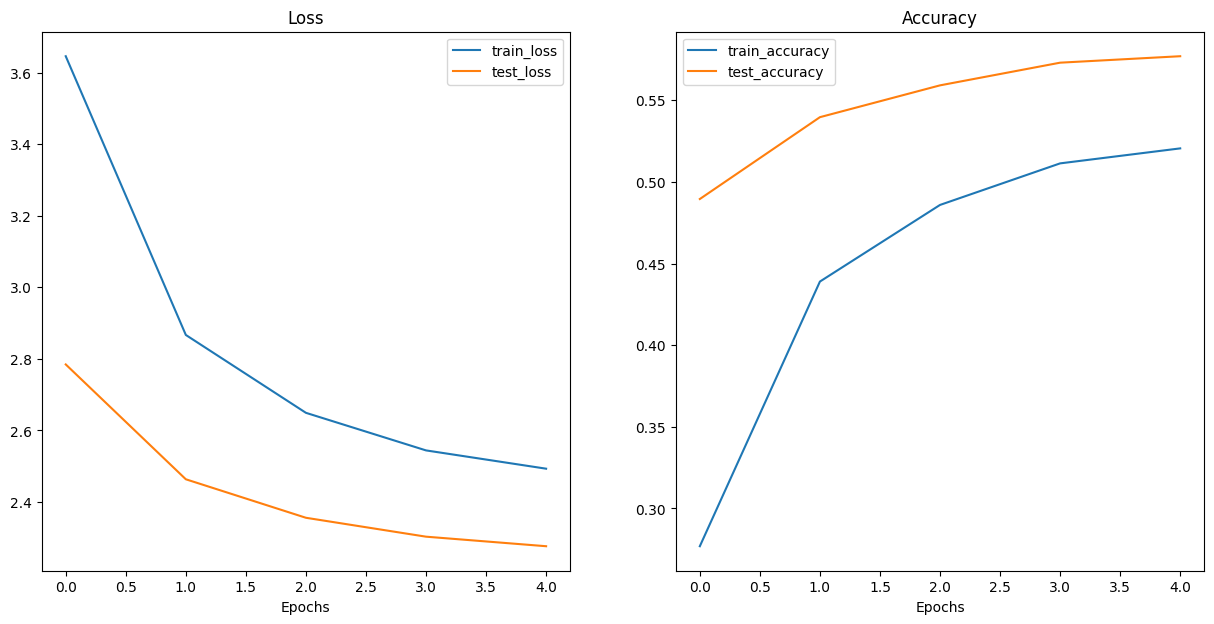

In [145]:
import helper_functions
from helper_functions import plot_loss_curves 
plot_loss_curves(effnetb2_food101_results)



In [147]:
from going_modular.going_modular import utils 
effnetb2_food_model101_path = "09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth"
utils.save_model(model=effnetb2_food101,target_dir="models/",model_name=effnetb2_food_model101_path)

[INFO] Saving model to: models/09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth


In [149]:
loaded_effnetb2_food101,effnetb2_transforms= create_effnetb2_model(num_classes=101)
loaded_effnetb2_food101.load_state_dict(torch.load("models/09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth"))

<All keys matched successfully>

In [152]:
from pathlib import Path 
pretrained_effnetb2_food101_model_size=Path("models",effnetb2_food_model101_path).stat().st_size//(1024*1024)
print(pretrained_effnetb2_food101_model_size)

30


In [153]:
foodvision_big_demo_path=Path("demos/foodvision_big/")
foodvision_big_demo_path.mkdir(parents=True,exist_ok=True)
(foodvision_big_demo_path / "examples").mkdir(parents=True,exist_ok=True)

In [154]:
# Download and move an example image
!wget https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg 
!mv 04-pizza-dad.jpeg demos/foodvision_big/examples/04-pizza-dad.jpg

# Move trained model to FoodVision Big demo folder (will error if model is already moved)
!mv models/09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth demos/foodvision_big

--2026-01-10 00:10:18--  https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.111.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 2874848 (2٫7M) [image/jpeg]
Saving to: ‘04-pizza-dad.jpeg’

04-pizza-dad.jpeg   100%[===================>]   2٫74M  50٫9KB/s    in 69s     

2026-01-10 00:11:28 (40٫8 KB/s) - ‘04-pizza-dad.jpeg’ saved [2874848/2874848]



In [157]:
food101_class_names = train_data.classes

food101_class_names[:10]


['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [158]:
# Create path to Food101 class names
foodvision_big_class_names_path = foodvision_big_demo_path / "class_names.txt"

# Write Food101 class names list to file
with open(foodvision_big_class_names_path, "w") as f:
    print(f"[INFO] Saving Food101 class names to {foodvision_big_class_names_path}")
    f.write("\n".join(food101_class_names)) # leave a new line between each class

[INFO] Saving Food101 class names to demos/foodvision_big/class_names.txt


In [159]:
with open (foodvision_big_class_names_path,"r") as f:
    food101_class_names_loaded = [food.strip() for food in f.readline()]
    

In [160]:
%%writefile demos/foodvision_big/model.py
import torch
import torchvision

from torch import nn


def create_effnetb2_model(num_classes:int=3, 
                          seed:int=42):
    """Creates an EfficientNetB2 feature extractor model and transforms.

    Args:
        num_classes (int, optional): number of classes in the classifier head. 
            Defaults to 3.
        seed (int, optional): random seed value. Defaults to 42.

    Returns:
        model (torch.nn.Module): EffNetB2 feature extractor model. 
        transforms (torchvision.transforms): EffNetB2 image transforms.
    """
    # Create EffNetB2 pretrained weights, transforms and model
    weights = torchvision.models.EfficientNet_B2_Weights.DEFAULT
    transforms = weights.transforms()
    model = torchvision.models.efficientnet_b2(weights=weights)

    # Freeze all layers in base model
    for param in model.parameters():
        param.requires_grad = False

    # Change classifier head with random seed for reproducibility
    torch.manual_seed(seed)
    model.classifier = nn.Sequential(
        nn.Dropout(p=0.3, inplace=True),
        nn.Linear(in_features=1408, out_features=num_classes),
    )
    
    return model, transforms

Writing demos/foodvision_big/model.py


In [ ]:
%%writefile demos/foodvision_big/app.py

import gradio as gr 
import os 
import torch 
from model import create_effnetb2_model 
from timeit import default_timer as timer 
from typing import Tuple , Dict 

with open ("class_names.txt", "r")as f:
    class_names= [food_name.strip() for food_name in f.readlines()]


effnetb2, effnetb2_transforms = create_effnetb2_model(num_classes=101)
effnetb2.load_state_dict(
    torch.load(
        f="09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth",
        map_location=torch.device("cpu"),  # load to CPU
    )
)

def predict(img) -> Tuple[Dict, float]:
    """Transforms and performs a prediction on img and returns prediction and time taken.
    """
    # Start the timer
    start_time = timer()
    
    # Transform the target image and add a batch dimension
    img = effnetb2_transforms(img).unsqueeze(0)
    
    # Put model into evaluation mode and turn on inference mode
    effnetb2.eval()
    with torch.inference_mode():
        # Pass the transformed image through the model and turn the prediction logits into prediction probabilities
        pred_probs = torch.softmax(effnetb2(img), dim=1)
    
    # Create a prediction label and prediction probability dictionary for each prediction class (this is the required format for Gradio's output parameter)
    pred_labels_and_probs = {class_names[i]: float(pred_probs[0][i]) for i in range(len(class_names))}
    
    # Calculate the prediction time
    pred_time = round(timer() - start_time, 5)
    
    # Return the prediction dictionary and prediction time 
    return pred_labels_and_probs, pred_time

title = "FoodVision Big "
description = "An EfficientNetB2 feature extractor computer vision model to classify images of food into [101 different classes](https://github.com/mrdbourke/pytorch-deep-learning/blob/main/extras/food101_class_names.txt)."
article = "Created at [09. PyTorch Model Deployment](https://www.learnpytorch.io/09_pytorch_model_deployment/)."

# Create examples list from "examples/" directory
example_list = [["examples/" + example] for example in os.listdir("examples")]

# Create Gradio interface 
demo = gr.Interface(
    fn=predict,
    inputs=gr.Image(type="pil"),
    outputs=[
        gr.Label(num_top_classes=5, label="Predictions"),
        gr.Number(label="Prediction time (s)"),
    ],
    examples=example_list,
    title=title,
    description=description,
    article=article,
)

# Launch the app!
demo.launch()


Overwriting demos/foodvision_big/app.py


In [163]:
%%writefile demos/foodvision_big/requirements.txt
torch ==2.9.1
torchvision ==0.24.1
gradio ==6.2.0


Writing demos/foodvision_big/requirements.txt


In [164]:
# Zip foodvision_big folder but exclude certain files
!cd demos/foodvision_big && zip -r ../foodvision_big.zip * -x "*.pyc" "*.ipynb" "*__pycache__*" "*ipynb_checkpoints*"


  adding: 09_pretrained_effnetb2_feature_extractor_food101_20_percent.pth (deflated 8%)
  adding: app.py (deflated 54%)
  adding: class_names.txt (deflated 48%)
  adding: examples/ (stored 0%)
  adding: examples/04-pizza-dad.jpg (deflated 0%)
  adding: model.py (deflated 56%)
  adding: requirements.txt (deflated 8%)
